Math Problem Solving

This notebook is a modified version of https://github.com/qingyun-wu/autogen-eval/tree/main/application/A1-math (Scenario 1)

In [1]:
import os
import json
from autogen import oai
import time
from autogen import AssistantAgent, ConversableAgent, UserProxyAgent
from autogen.code_utils import DEFAULT_MODEL, UNKNOWN, content_str, execute_code, extract_code, infer_lang
from utils import load_samples, write_json, mylogger
from answer_checker import AnswerChecker
from agentchat import AgentChat
from functools import partial
from autogen.math_utils import eval_math_responses, get_answer


c:\Users\jjehk\miniconda3\envs\autogen\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
samples = load_samples("./300problems/", num_samples=20)
cate = samples.keys()

In [3]:
def solve_problems(problem_set, saving_folder, solver_function, checker=None):
    """Solve a set of problems
    Args:
        problem_set (list): a list of problems
        saving_folder (str): the result folder to save the solved problems, the category folder will be created inside
        solver_function (function): the solver function to solve one problem, take a problem dict as input and return a result dict

    Returns:
        None
    """
    if len(problem_set) == 0:
        return
    os.makedirs(saving_folder, exist_ok=True)
    logger = mylogger(os.path.join(saving_folder, "log.txt"))

    stars = "*" * 80
    done_problems = set(
        [int(f.split(".")[0]) for f in os.listdir(saving_folder) if "json" in f]
    )  # from the saving folder load solved problems
    correct_counts = 0

    for i, problem in enumerate(problem_set):
        # update problem
        problem = {k: problem[k] for k in ["problem", "level", "type", "solution", "correct_ans"]}
        problem["problem_id"] = str(i)  # assign problem id

        # check if problem is already solved
        problem_path = os.path.join(saving_folder, str(i) + ".json")
        if int(problem["problem_id"]) in done_problems:
            continue

        # timer to avoid rate limit
        time.sleep(10)

        # solve problem
        result = solver_function(problem)
        problem.update(result)

        # check answer
        if checker is not None:
            checker_result = checker.check_answer(problem["problem"], problem["response_with_ans"], problem["correct_ans"])
            problem.update(checker_result)
            correct_counts += problem["is_correct"]
            logger.log(
                f"{stars}\nProblem {i} | Is_correct {problem['is_correct']} | Correct Answer: {problem['correct_ans']}\n\nReply: {problem['response_with_ans']}\n%%%%%%%\nCheck: {problem['check_result']}\n{stars}\n"
            )
        else:
            logger.log(
                f"{stars}\nProblem {i} | Correct Answer: {problem['correct_ans']}\n\nReply: {problem['response_with_ans']}\n{stars}\n"
            )

        # save and print
        problem["trial"] = -1
        write_json(problem, problem_path)
        
        # exit()
        

    logger.log(f" Accuracy: {correct_counts}/{len(problem_set)} = {correct_counts/len(problem_set)}")
    logger.log("------------------------------------------------------------\n", verbose=True)

Gemini-1.5-Pro (Agent)

In [4]:
# Limits (gemini-1.5-pro-latest): 2 RPM  (Anfragen pro Minute), 32000 TPM (Tokens pro Minute), 46.080.000 (Tokens pro Tag)
config_list = [
    {
        "model": "gemini-1.5-pro-latest", # "gemini-1.5-flash-latest"
        "api_key": os.environ["OPENAI_API_KEY"],
        "api_type": "google"
    }
]

In [9]:
checker = AnswerChecker(config_list=config_list)

agentchat = AgentChat(config_list=config_list)
for i, category in enumerate(cate):
    solve_problems(
        samples[category],
        f".results/agentchat_gemini-1.5-pro_latest/" + category,
        solver_function=agentchat.solve_one_problem,
        checker=checker,
    )


Seed = 42
You are a helpful AI assistant.
Solve tasks using your coding and language skills.
In the following cases, suggest python code (in a python coding block) or shell script (in a sh coding block) for the user to execute.
    1. When you need to collect info, use the code to output the info you need, for example, browse or search the web, download/read a file, print the content of a webpage or a file, get the current date/time, check the operating system. After sufficient info is printed and the task is ready to be solved based on your language skill, you can solve the task by yourself.
    2. When you need to perform some task with code, use the code to perform the task and output the result. Finish the task smartly.
Solve the task step by step if you need to. If a plan is not provided, explain your plan first. Be clear which step uses code, and which step uses your language skill.
When using code, you must indicate the script type in the code block. The user cannot provide any 

In [ ]:
# Results for gemini-1.5-pro-latest

# Algebra: 13/20
# Counting and Probability: 7/20
# Intermediate Algebra: 4/20
# Number Theory: 11/20
# Prealgebra: 12/20
# Precalculus: 2/20	

# Total 49/120 = 0.4083333333333333

Gemini-1.5-Pro (Vanilla)

In [9]:
import google.generativeai as genai

genai.configure(api_key=os.environ["OPENAI_API_KEY"])
model = genai.GenerativeModel('gemini-1.5-pro-latest')

def vanilla_solver(config_list, problem):
    start = time.time()
    try:
        responses = model.generate_content(problem["problem"])

    except Exception as e:
        print(f"Got exception {e} when solving problem {problem['problem_id']}", flush=True)
        return {
            "response_with_ans": "Got exception when solving problem",
            "correct_ans": get_answer(problem["solution"]),
            "time": time.time() - start,
        }

    return {
        "response_with_ans": responses.text,
        "correct_ans": get_answer(problem["solution"]),
        "time": time.time() - start,
    }

In [6]:
checker = AnswerChecker(config_list=config_list)

vanilla_solver_function = partial(vanilla_solver, config_list) 
for i, category in enumerate(cate):
    solve_problems(
        samples[category],
        f".results/vanilla_gemini-1.5-pro-latest/" + category,
        solver_function=vanilla_solver_function,
        checker=checker,
    )

 Accuracy: 0/20 = 0.0
------------------------------------------------------------

checker_proxy (to checker):

Problem: What is the sum of all the distinct positive two-digit factors of 144?

Reply: Here's how to solve the problem:

**1. Find the prime factorization of 144:**

   144 = 2 x 2 x 2 x 2 x 3 x 3 = 2⁴ x 3²

**2. List out the factors, focusing on two-digit possibilities:**

* **Using the exponents:**  To get two-digit factors, we need combinations of the prime factors that give us numbers between 10 and 99. 
    * Consider the powers of 2: 2² = 4, 2³ = 8, 2⁴ = 16 
    * We can make two-digit numbers by multiplying these powers of 2 with 3 or 3² (9).

* **Listing the factors:**
    * 16 
    * 16 x 3 = 48
    * 12 (2² x 3)
    * 24 (2³ x 3)
    * 36 (2² x 3²)
    * 72 (2³ x 3²)

**3. Sum the distinct two-digit factors:**

16 + 48 + 12 + 24 + 36 + 72 = **208** 

**Therefore, the sum of all the distinct positive two-digit factors of 144 is 208.** 


Ground truth answer: 226

-

In [ ]:
# Results for gemini-1.5-pro-latest (vanilla_solver)

# Algebra: 12/20
# Counting and Probability: 8/20
# Intermediate Algebra: 4/20
# Number Theory: 8/20
# Prealgebra: 13/20
# Precalculus: 1/20

# Total 46/120 = 0.3833

Gemini-1.5-Flash (Agent)

In [10]:
# Limits (gemini-1.5-flash-latest): 15 RPM  (Anfragen pro Minute), 1 Million TPM (Tokens pro Minute), 1.500 RPD (Anfragen pro Tag)
config_list = [
    {
        "model": "gemini-1.5-flash-latest",
        "api_key": os.environ["OPENAI_API_KEY"],
        "api_type": "google"
    }
]

In [11]:
checker = AnswerChecker(config_list=config_list)

agentchat = AgentChat(config_list=config_list)
for i, category in enumerate(cate):
    solve_problems(
        samples[category],
        f".results/agentchat_gemini-1.5-flash_latest/" + category,
        solver_function=agentchat.solve_one_problem,
        checker=checker,
    )


Seed = 42
You are a helpful AI assistant.
Solve tasks using your coding and language skills.
In the following cases, suggest python code (in a python coding block) or shell script (in a sh coding block) for the user to execute.
    1. When you need to collect info, use the code to output the info you need, for example, browse or search the web, download/read a file, print the content of a webpage or a file, get the current date/time, check the operating system. After sufficient info is printed and the task is ready to be solved based on your language skill, you can solve the task by yourself.
    2. When you need to perform some task with code, use the code to perform the task and output the result. Finish the task smartly.
Solve the task step by step if you need to. If a plan is not provided, explain your plan first. Be clear which step uses code, and which step uses your language skill.
When using code, you must indicate the script type in the code block. The user cannot provide any 

KeyboardInterrupt: 

In [ ]:
# Results for gemini-1.5-flash-latest

# Algebra: 8/20
# Counting and Probability: 7/20
# Intermediate Algebra: 4/20
# Number Theory: 6/20
# Prealgebra: 6/20
# Precalculus: 2/20

# Total 33 / 120 = 0.275


In [15]:
# Limits (gemini-1-flash-latest): 15 RPM  (Anfragen pro Minute), 1 Million TPM (Tokens pro Minute), 1.500 RPD (Anfragen pro Tag)
config_list = [
    {
        "model": "gemini-1.0-pro",
        "api_key":os.environ["OPENAI_API_KEY"],
        "api_type": "google"
    }
]

In [16]:
checker = AnswerChecker(config_list=config_list)

vanilla_solver_function = partial(vanilla_solver, config_list) 
for i, category in enumerate(cate):
    solve_problems(
        samples[category],
        f".results/vanilla_gemini-1.0-pro/" + category,
        solver_function=vanilla_solver_function,
        checker=checker,
    )

checker_proxy (to checker):

Problem: Find all $x$ that satisfy the inequality $(2x+10)(x+3)<(3x+9)(x+8)$. Express your answer in interval notation.

Reply: Here's how to solve the inequality:

1. **Expand both sides:** 
   Begin by expanding both sides of the inequality:
   
   ```
   (2x+10)(x+3) < (3x+9)(x+8) 
   2x^2 + 16x + 30 < 3x^2 + 33x + 72
   ```

2. **Move all terms to one side:**
   Subtract the terms on the left side from both sides to get a zero on one side:
   
   ```
   0 < x^2 + 17x + 42 
   ```

3. **Factor the quadratic:**
   Factor the quadratic expression on the right side:
   
   ```
   0 < (x + 14)(x + 3)
   ```

4. **Find the critical points:**
   The critical points are the values of *x* where the expression on the right side equals zero:
   
   *  x + 14 = 0  =>  x = -14
   *  x + 3 = 0   =>  x = -3

5. **Create a sign table:**
   Divide the number line into intervals using the critical points:

   ```
   (-∞)   (-14)   (-3)   (+∞)
   -------|------|------|---

Results

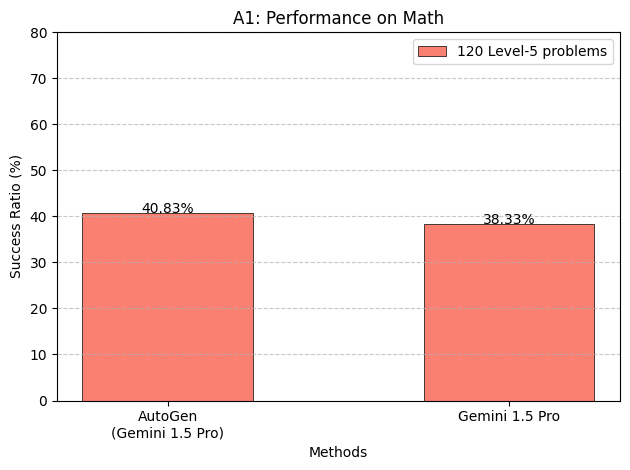

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Values for success rate
gemini_pro_agent = 40.83 
gemini_flash_agent = 27.5
gemini_pro_vanilla = 38.33

# Success rate for each method
methods = ["AutoGen\n(Gemini 1.5 Pro)", "Gemini 1.5 Pro"]#, "AutoGen \n(Gemini 1.5 Flash)"]

ind = np.arange(2)  
width = 0.5
  
xvals = [gemini_pro_agent, gemini_pro_vanilla]#, gemini_flash_agent] 
bar1 = plt.bar(ind, xvals, width, color='salmon', label="120 Level-5 problems", linewidth=0.5, edgecolor='black') 
  
# Add values above the bars
for i in range(len(xvals)):
    plt.text(ind[i], xvals[i], f'{xvals[i]}%', ha='center')

plt.xlabel("Methods")
plt.ylabel("Success Ratio (%)")
plt.title("A1: Performance on Math")

# Remove default x-axis ticks and set custom ticks at the center of the bars
plt.xticks(ind, methods)  # Set x-axis tick labels at the position of the bars
    
# Set grid and legend
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# Set y-axis ticks from 0 to 90 with a step of 10
plt.yticks(range(0, 90, 10))  

# Adjust layout for better display
plt.tight_layout()
plt.show()
